In [52]:
import pandas as pd  # data handling and analysis
import numpy as np   # numerical computing

In [53]:
# Load the weather sensor data form notebook Input (panel in the right you can see the input and output)
weather_df = pd.read_csv('Plant_1_Weather_Sensor_Data.csv')

# Load the generation (power output) data  form notebook Input (panel in the right you can see the input and output)
generation_df = pd.read_csv('Plant_1_Generation_Data.csv')

# Show the first 5 rows of each dataset with '.head()' method
print("Weather Data Sample:")
display(weather_df.head())

print("Generation Data Sample:")
display(generation_df.head())

Weather Data Sample:


,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0


Generation Data Sample:


,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


In [54]:
weather_df.tail()

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
3177,2020-06-17 22:45:00,4135001,HmiyD2TTLFNqkNe,22.150570,21.480377,0.0
3178,2020-06-17 23:00:00,4135001,HmiyD2TTLFNqkNe,22.129816,21.389024,0.0
3179,2020-06-17 23:15:00,4135001,HmiyD2TTLFNqkNe,22.008275,20.709211,0.0
3180,2020-06-17 23:30:00,4135001,HmiyD2TTLFNqkNe,21.969495,20.734963,0.0
3181,2020-06-17 23:45:00,4135001,HmiyD2TTLFNqkNe,21.909288,20.427972,0.0


In [55]:
generation_df.tail()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
68773,17-06-2020 23:45,4135001,uHbuxQJl8lW7ozc,0.0,0.0,5967.000,7287002.0
68774,17-06-2020 23:45,4135001,wCURE6d3bPkepu2,0.0,0.0,5147.625,7028601.0
68775,17-06-2020 23:45,4135001,z9Y9gH1T5YWrNuG,0.0,0.0,5819.000,7251204.0
68776,17-06-2020 23:45,4135001,zBIq5rxdHJRwDNY,0.0,0.0,5817.000,6583369.0
68777,17-06-2020 23:45,4135001,zVJPv84UY57bAof,0.0,0.0,5910.000,7363272.0


In [56]:
print(
    'The number of inverter for data_time {} is {}'.format(
        '15-05-2020 23:00', generation_df[generation_df.DATE_TIME == '15-05-2020 23:00']['SOURCE_KEY'].nunique())
)

The number of inverter for data_time 15-05-2020 23:00 is 22


In [57]:
# Convert timestamps to datetime 
weather_df['DATE_TIME'] = pd.to_datetime(weather_df['DATE_TIME'],dayfirst=True)
generation_df['DATE_TIME'] = pd.to_datetime(generation_df['DATE_TIME'],dayfirst=True)

# Find timestamps that exist in weather but not in generation
missing_in_generation = weather_df[~weather_df['DATE_TIME'].isin(generation_df['DATE_TIME'])]
print(f"Missing timestamps in generation data: {len(missing_in_generation)}")

Missing timestamps in generation data: 25


C:\Users\mayan\AppData\Local\Temp\ipykernel_22428\2576518576.py:2: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  weather_df['DATE_TIME'] = pd.to_datetime(weather_df['DATE_TIME'],dayfirst=True)


In [58]:
missing_in_generation

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
542,2020-05-20 23:00:00,4135001,HmiyD2TTLFNqkNe,23.830852,21.024118,0.000000
543,2020-05-20 23:15:00,4135001,HmiyD2TTLFNqkNe,23.701162,20.786399,0.000000
544,2020-05-20 23:30:00,4135001,HmiyD2TTLFNqkNe,23.589626,20.572882,0.000000
545,2020-05-20 23:45:00,4135001,HmiyD2TTLFNqkNe,23.569009,20.622103,0.000000
546,2020-05-21 00:00:00,4135001,HmiyD2TTLFNqkNe,23.497382,20.584137,0.000000
547,2020-05-21 00:15:00,4135001,HmiyD2TTLFNqkNe,23.228943,20.230347,0.000000
548,2020-05-21 00:30:00,4135001,HmiyD2TTLFNqkNe,23.204518,20.179942,0.000000
731,2020-05-23 05:15:00,4135001,HmiyD2TTLFNqkNe,21.900024,20.994995,0.000000
919,2020-05-25 05:45:00,4135001,HmiyD2TTLFNqkNe,22.930503,21.104395,0.001908
1274,2020-05-28 22:30:00,4135001,HmiyD2TTLFNqkNe,21.259225,20.277036,0.000000


In [59]:
# Step 1: Group by timestamp and sum across inverters
generation_grouped = generation_df.groupby('DATE_TIME')[['DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD']].sum()

# Step 2: Reindex to match the weather timestamps exactly
# This keeps missing timestamps and fills them with zeros
generation_grouped = generation_grouped.reindex(weather_df['DATE_TIME']).fillna(0)

# Step 3: Reset index to make DATE_TIME a column again
generation_grouped = generation_grouped.reset_index().rename(columns={'index': 'DATE_TIME'})

In [60]:
weather_df_idx = weather_df.set_index('DATE_TIME')
generation_idx = generation_grouped.set_index('DATE_TIME')

display(weather_df_idx.describe())
display(generation_idx.describe())

,PLANT_ID,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
count,3182.0,3182.000000,3182.000000,3182.000000
mean,4135001.0,25.531606,31.091015,0.228313
std,0.0,3.354856,12.261222,0.300836
min,4135001.0,20.398505,18.140415,0.000000
25%,4135001.0,22.705182,21.090553,0.000000
50%,4135001.0,24.613814,24.618060,0.024653
75%,4135001.0,27.920532,41.307840,0.449588
max,4135001.0,35.252486,65.545714,1.221652


,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
count,3182.000000,3182.000000,3182.000000,3.182000e+03
mean,68021.364537,6652.152733,71234.359461,1.508344e+08
std,87917.828216,8590.766175,66024.338720,1.694573e+07
min,0.000000,0.000000,0.000000,0.000000e+00
25%,0.000000,0.000000,10.982143,1.520026e+08
50%,7512.333333,726.013988,66060.455358,1.535195e+08
75%,139358.133927,13649.681696,129056.477679,1.549854e+08
max,298937.785710,29150.212499,193770.000000,1.561428e+08


In [61]:
# Check if both indexes are equal
print("Indexes are equal:" , weather_df_idx.index.equals(generation_idx.index))

Indexes are equal: True


In [62]:
weather_df_idx = weather_df_idx.drop(['PLANT_ID', 'SOURCE_KEY'], axis=1)
weather_df_idx.head()

,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
DATE_TIME,,,
2020-05-15 00:00:00,25.184316,22.857507,0.0
2020-05-15 00:15:00,25.084589,22.761668,0.0
2020-05-15 00:30:00,24.935753,22.592306,0.0
2020-05-15 00:45:00,24.846130,22.360852,0.0
2020-05-15 01:00:00,24.621525,22.165423,0.0


In [63]:
generation_idx.columns

Index(['DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD'], dtype='object')

In [64]:
generation_idx = generation_idx.drop(['DC_POWER', 'TOTAL_YIELD'], axis=1)
generation_idx.head()

,AC_POWER,DAILY_YIELD
DATE_TIME,,
2020-05-15 00:00:00,0.0,0.0
2020-05-15 00:15:00,0.0,0.0
2020-05-15 00:30:00,0.0,0.0
2020-05-15 00:45:00,0.0,0.0
2020-05-15 01:00:00,0.0,0.0


In [65]:
df = pd.merge(generation_idx, weather_df_idx, on='DATE_TIME')
df.head()

,AC_POWER,DAILY_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
DATE_TIME,,,,,
2020-05-15 00:00:00,0.0,0.0,25.184316,22.857507,0.0
2020-05-15 00:15:00,0.0,0.0,25.084589,22.761668,0.0
2020-05-15 00:30:00,0.0,0.0,24.935753,22.592306,0.0
2020-05-15 00:45:00,0.0,0.0,24.846130,22.360852,0.0
2020-05-15 01:00:00,0.0,0.0,24.621525,22.165423,0.0


eda

In [66]:
df = pd.merge(generation_idx, weather_df_idx, on='DATE_TIME')
df.head()

,AC_POWER,DAILY_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
DATE_TIME,,,,,
2020-05-15 00:00:00,0.0,0.0,25.184316,22.857507,0.0
2020-05-15 00:15:00,0.0,0.0,25.084589,22.761668,0.0
2020-05-15 00:30:00,0.0,0.0,24.935753,22.592306,0.0
2020-05-15 00:45:00,0.0,0.0,24.846130,22.360852,0.0
2020-05-15 01:00:00,0.0,0.0,24.621525,22.165423,0.0


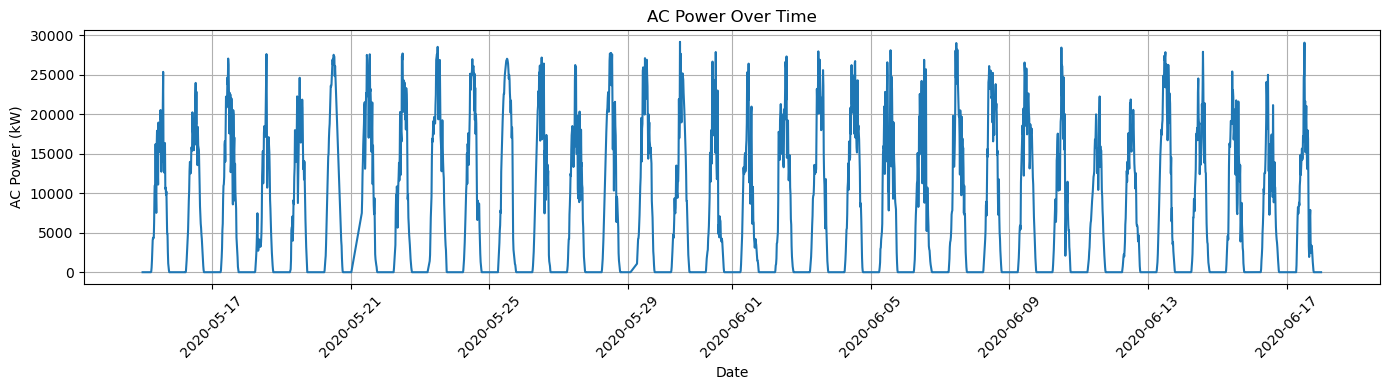

In [67]:
#ac vs time
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 4))
plt.plot(df.index, df['AC_POWER'])
plt.title('AC Power Over Time')
plt.xlabel('Date')
plt.ylabel('AC Power (kW)')
plt.grid(True)
plt.xticks(rotation=45)  
plt.tight_layout()
plt.show()

In [68]:
import ipywidgets as widgets
from IPython.display import display

# Convert to datetime
df = df.reset_index()
df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'])

# Add a date column
df['DATE'] = df['DATE_TIME'].dt.date

# Get sorted list of available days
unique_days = sorted(df['DATE'].unique())

# Create dropdown widget
day_selector = widgets.Dropdown(
    options=unique_days,
    description='Select Date:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='50%')
)
# Define plot function
def plot_day(selected_day):
    # Filter the DataFrame for that day
    day_data = df[df['DATE'] == selected_day]
    
    # Set up the plot
    fig, ax1 = plt.subplots(figsize=(12, 4))
    
    # Left axis: Irradiation
    ax1.plot(day_data['DATE_TIME'], day_data['IRRADIATION'], color='tab:blue', label='Irradiation')
    ax1.set_ylabel('Irradiation (kW/m²)', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    
    # Right axis: AC Power (kW)
    ax2 = ax1.twinx()
    ax2.plot(day_data['DATE_TIME'], day_data['AC_POWER'], color='tab:orange', label='AC Power')
    ax2.set_ylabel('AC Power (kW)', color='tab:orange')
    ax2.tick_params(axis='y', labelcolor='tab:orange')

    plt.title(f'Irradiation and AC Power on {selected_day}')
    plt.grid(True)
    fig.tight_layout()
    plt.show()

# Connect dropdown to function
widgets.interact(plot_day, selected_day=day_selector);

interactive(children=(Dropdown(description='Select Date:', layout=Layout(width='50%'), options=(datetime.date(…

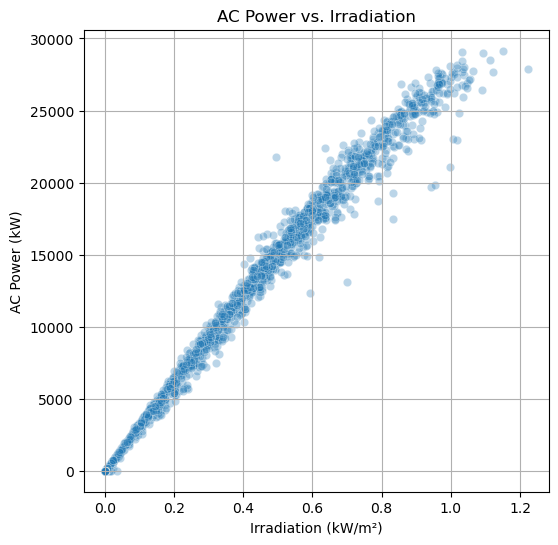

In [69]:
plt.figure(figsize=(6, 6))
import seaborn as sns
# Create the scatter plot
sns.scatterplot(data=df, x='IRRADIATION', y='AC_POWER', alpha=0.3)

# Labels and styling
plt.title('AC Power vs. Irradiation')
plt.xlabel('Irradiation (kW/m²)')
plt.ylabel('AC Power (kW)')
plt.grid(True)
plt.show()

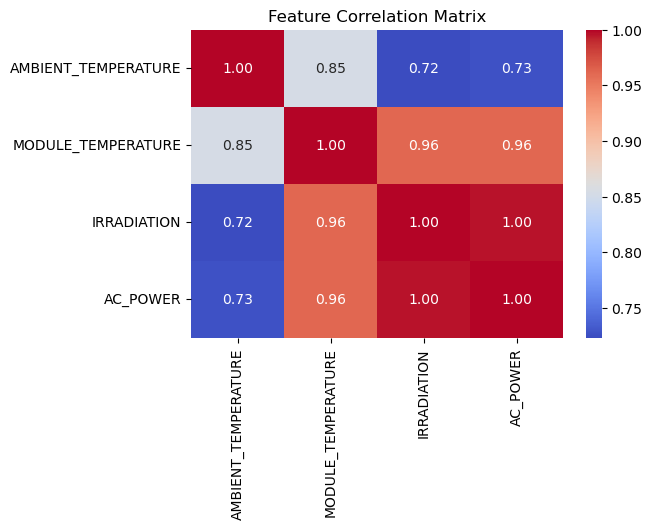

In [70]:
'''Feature Correlation Heatmap
This heatmap helps us understand how strongly different features are related to each other.

In particular, we’re interested in how:

Irradiation, Ambient Temperature, and Module Temperature correlate with the output variable, AC Power.
Correlation values range from -1 (perfect negative) to 1 (perfect positive).

A strong positive correlation between Irradiation and AC Power makes sense — more sunlight usually means more energy production.

'''
# relevant numeric columns for correlation
correlation_columns = ['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION', 'AC_POWER']
corr_matrix = df[correlation_columns].corr()

# Plot the heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix')
plt.show()


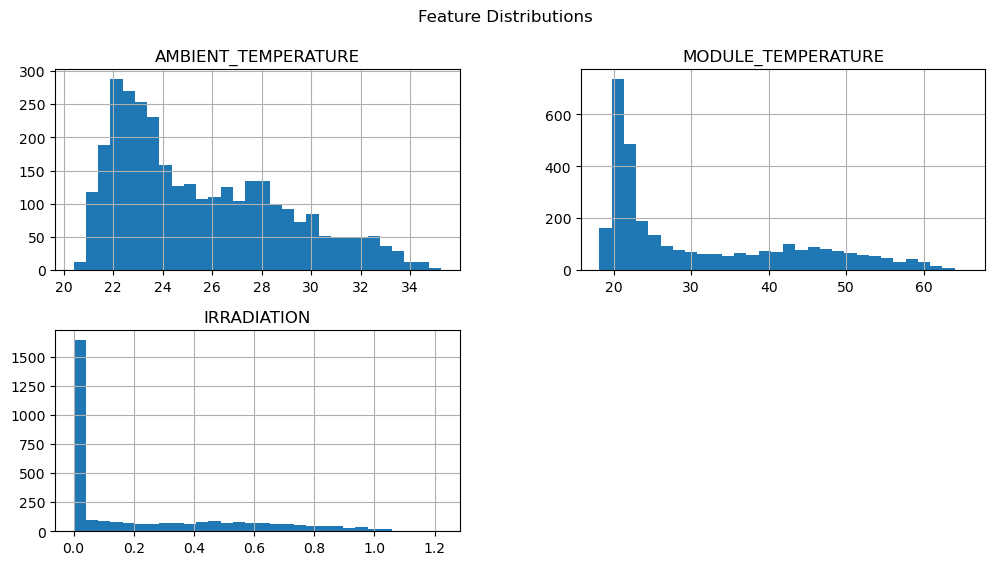

In [71]:
'''This plot shows the distribution (histogram) of the three input features:

AMBIENT_TEMPERATURE

MODULE_TEMPERATURE

IRRADIATION

Understanding feature distributions helps us:

Detect skewness, outliers, or non-normal patterns

Decide if whether transformation or normalization is needed

See how often low or high values occur (e.g., most irradiation values are near zero due to night time)

'''
df[['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']].hist(
    figsize=(12, 6), bins=30
)
plt.suptitle('Feature Distributions')
plt.show()

preparing data for training 


In [72]:
df = pd.merge(generation_idx, weather_df_idx, on='DATE_TIME')
df.describe()

,AC_POWER,DAILY_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
count,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000
mean,6652.152733,71234.359461,25.531606,31.091015,0.228313
std,8590.766175,66024.338720,3.354856,12.261222,0.300836
min,0.000000,0.000000,20.398505,18.140415,0.000000
25%,0.000000,10.982143,22.705182,21.090553,0.000000
50%,726.013988,66060.455358,24.613814,24.618060,0.024653
75%,13649.681696,129056.477679,27.920532,41.307840,0.449588
max,29150.212499,193770.000000,35.252486,65.545714,1.221652


In [73]:
# Reset Index
df = df.reset_index()

# Convert the date_time column to datetime format
df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'])

# Add a date column
df['DATE'] = df['DATE_TIME'].dt.date

df.head()

,DATE_TIME,AC_POWER,DAILY_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,DATE
0,2020-05-15 00:00:00,0.0,0.0,25.184316,22.857507,0.0,2020-05-15
1,2020-05-15 00:15:00,0.0,0.0,25.084589,22.761668,0.0,2020-05-15
2,2020-05-15 00:30:00,0.0,0.0,24.935753,22.592306,0.0,2020-05-15
3,2020-05-15 00:45:00,0.0,0.0,24.846130,22.360852,0.0,2020-05-15
4,2020-05-15 01:00:00,0.0,0.0,24.621525,22.165423,0.0,2020-05-15


In [75]:
# drooping duplicates
unique_dates = df['DATE'].drop_duplicates().values

In [76]:
# 1. Shuffle the dates
np.random.seed(42)
np.random.shuffle(unique_dates)

# 2. Split the dates into train/test sets
split_ratio = 0.8
split_index = int(len(unique_dates) * split_ratio)
train_dates = unique_dates[:split_index]
test_dates  = unique_dates[split_index:]

# 3. Use those dates to select rows from df
train_df = df[df['DATE'].isin(train_dates)]
test_df  = df[df['DATE'].isin(test_dates)]

In [77]:
# Select features and target

features = ['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']
target = 'AC_POWER'

In [78]:
from sklearn.preprocessing import MinMaxScaler

# Initialize scalers
X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

# Fit only on training data
X_train = X_scaler.fit_transform(train_df[features])
y_train = y_scaler.fit_transform(train_df[[target]])

# Transform the test data
X_test = X_scaler.transform(test_df[features])
y_test = y_scaler.transform(test_df[[target]])

In [79]:
print('The X_train shape is:', X_train.shape)
print('The y_train shape is:', y_train.shape)

print('The X_test shape is:', X_test.shape)
print('The y_test shape is:', y_test.shape)

The X_train shape is: (2555, 3)
The y_train shape is: (2555, 1)
The X_test shape is: (627, 3)
The y_test shape is: (627, 1)


In [80]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Input, Dense

In [82]:
activation_function = 'sigmoid'

model.add(Dense(1, activation=activation_function))


In [83]:
model = keras.Sequential()
model.add(Input(shape=(X_train.shape[1],)))   # Input layer
model.add(Dense(1, activation=activation_function)) # Output layer 

In [84]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = model.fit(X_train, y_train, epochs=20, validation_split=0.2, verbose=1)

Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1846 - mae: 0.3890 - val_loss: 0.1759 - val_mae: 0.3800
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1731 - mae: 0.3777 - val_loss: 0.1647 - val_mae: 0.3683
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1626 - mae: 0.3673 - val_loss: 0.1545 - val_mae: 0.3571
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1530 - mae: 0.3573 - val_loss: 0.1452 - val_mae: 0.3466
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1441 - mae: 0.3476 - val_loss: 0.1368 - val_mae: 0.3368
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1360 - mae: 0.3383 - val_loss: 0.1287 - val_mae: 0.3273
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1284 - mae: 0.3292 - val_loss: 0.1215 - val_mae: 0.3185
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1213 - mae: 0.3204 - val_loss: 0.1148 - val_mae: 0.3099
Epoch 9/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1147 - mae: 

In [85]:
loss, mae = model.evaluate(X_test, y_test)
print(f"Test MAE: {mae:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0636 - mae: 0.2343
Test MAE: 0.2343


In [86]:
# 1. Predict on scaled test set
y_pred_scaled = model.predict(X_test).flatten()
y_true_scaled = y_test.flatten()

# 2. Inverse transform to original scale
y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_true = y_scaler.inverse_transform(y_true_scaled.reshape(-1, 1)).flatten()

# 3. Create DataFrame of results
results = pd.DataFrame({
    'true': y_true,
    'pred': y_pred
})

# Copy DATE_TIME from test_df (same order as y_test/y_pred)
results['DATE_TIME'] = test_df['DATE_TIME'].values

# Also extract the date part if you want per-day plots
results['DATE'] = pd.to_datetime(results['DATE_TIME']).dt.date

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


In [88]:
# 4. Evaluate performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred) ** 0.5
r2 = r2_score(y_true, y_pred)

print(f"MAE (kw): {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

MAE (kw): 6829.1571
RMSE: 7353.7098
R²: 0.3367


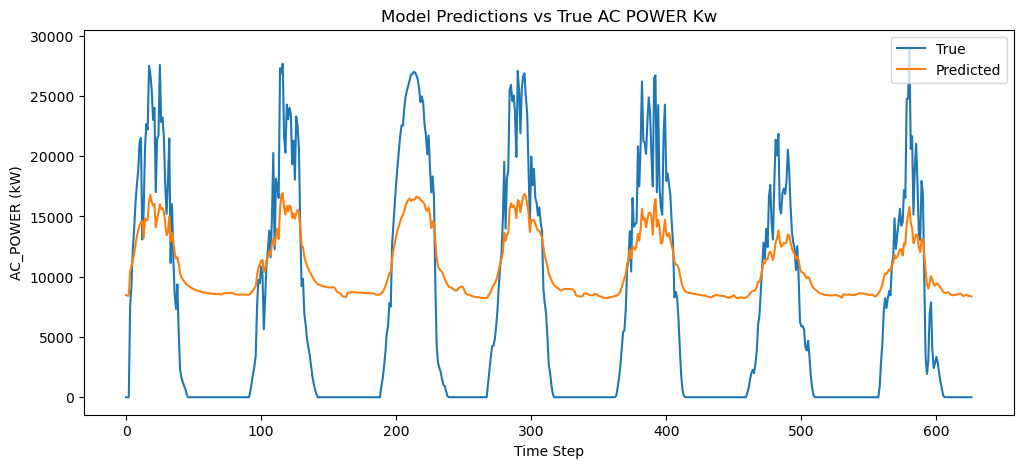

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(y_true, label='True')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.title('Model Predictions vs True AC POWER Kw')
plt.xlabel('Time Step')
plt.ylabel('AC_POWER (kW)')  
plt.show()